## Fast Food Marketing Campaign Performance Analysis
1. Environment Setup and Data Loading
In this initial phase, we import the essential Python libraries for data manipulation (pandas), visualization (matplotlib, seaborn), and statistical analysis (scipy.stats). We then load the marketing dataset from a local path and display the initial rows to verify the data structure.


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df = pd.read_csv(r"C:\Users\Renad\Downloads\WA_Marketing-Campaign.csv")

df.head()

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


## 2. Data Integrity and Exploratory Analysis
Before conducting statistical tests, we check for missing values to ensure data quality. We also generate summary statistics to understand the distribution of variables and count the number of locations assigned to each promotion group to ensure a balanced experimental design.


In [22]:
df.isnull().sum()

MarketID            0
MarketSize          0
LocationID          0
AgeOfStore          0
Promotion           0
week                0
SalesInThousands    0
dtype: int64

In [23]:
df.describe()

,MarketID,LocationID,AgeOfStore,Promotion,week,SalesInThousands
count,548.000000,548.000000,548.000000,548.000000,548.000000,548.000000
mean,5.715328,479.656934,8.503650,2.029197,2.500000,53.466204
std,2.877001,287.973679,6.638345,0.810729,1.119055,16.755216
min,1.000000,1.000000,1.000000,1.000000,1.000000,17.340000
25%,3.000000,216.000000,4.000000,1.000000,1.750000,42.545000
50%,6.000000,504.000000,7.000000,2.000000,2.500000,50.200000
75%,8.000000,708.000000,12.000000,3.000000,3.250000,60.477500
max,10.000000,920.000000,28.000000,3.000000,4.000000,99.650000


In [24]:
df.groupby('Promotion')['LocationID'].count()

Promotion
1    172
2    188
3    188
Name: LocationID, dtype: int64

## 3.Visual Comparison of Promotions

To visually assess which promotion is performing better, we use a Boxplot. This helps identify the median sales and detect potential outliers.

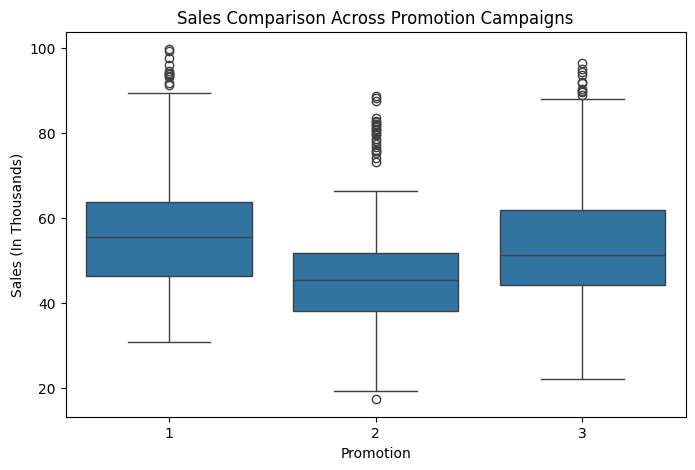

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Promotion', y='SalesInThousands', data=df)

plt.title('Sales Comparison Across Promotion Campaigns')
plt.ylabel('Sales (In Thousands)')
plt.show()

## 5.Confirmatory Data Analysis (CDA)
Statistical Significance: One-Way ANOVA

We test the null hypothesis (H₀):

"There is no significant difference between the mean sales of the three promotions."


In [26]:
p1 = df[df['Promotion'] == 1]['SalesInThousands']
p2 = df[df['Promotion'] == 2]['SalesInThousands']
p3 = df[df['Promotion'] == 3]['SalesInThousands']

f_stat, p_val = stats.f_oneway(p1, p2, p3)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_val:.4e}")

F-statistic: 21.9535
P-value: 6.7658e-10


## Post-hoc Analysis: Tukey HSD
To identify exactly which promotions differ, we use the pairwise_tukeyhsd function.

In [27]:
tukey = pairwise_tukeyhsd(
    endog=df['SalesInThousands'],
    groups=df['Promotion'],
    alpha=0.05
)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     1      2 -10.7696    0.0 -14.7738 -6.7654   True
     1      3  -2.7345 0.2444  -6.7388  1.2697  False
     2      3   8.0351    0.0   4.1208 11.9493   True
-----------------------------------------------------


## Mean Sales per Promotion Group

In [28]:
df.groupby('Promotion')['SalesInThousands'].mean()

Promotion
1    58.099012
2    47.329415
3    55.364468
Name: SalesInThousands, dtype: float64

## Summary & Next Steps
Key Findings

• Promotion Efficacy: Promotions 1 and 3 are statistically superior to Promotion 2.
• Market Influence: Market Size has a massive impact on sales (P-value ≈ 0). Large markets consistently outperform medium and small markets.
• Conclusion: The company should discontinue Promotion 2 and focus on 1 or 3, while prioritizing expansion in Large market sizes.

Future Work

• Perform a cost-benefit analysis for each promotion (ROI)
• Investigate the Week variable to see if there is a decay in promotion effectiveness over time